# Copying diagnostic on real generated images (Layer 7, Day 20)

`src/evaluation/copying.py` was built and self-tested on synthetic patches
in isolation. This notebook is the actual deliverable: run the two-stage
diagnostic (cheap hash candidates, then exact NCC confirmation) on a REAL
image generated by `sample_coarse_to_fine`, and report **own-group** vs
**other-group** edges separately - a generated image resembling its own
source is expected (the denoiser is built from that image's own patches by
design); resembling a different DOI group, or the hidden test set, is a
leak.


## 1. Generate one synthetic image from a real EMPS source

Own-group patches = real patches from the SAME source image the generator
used. Other-group patches = real patches from a DIFFERENT EMPS source
(different DOI) that had nothing to do with this generation run.

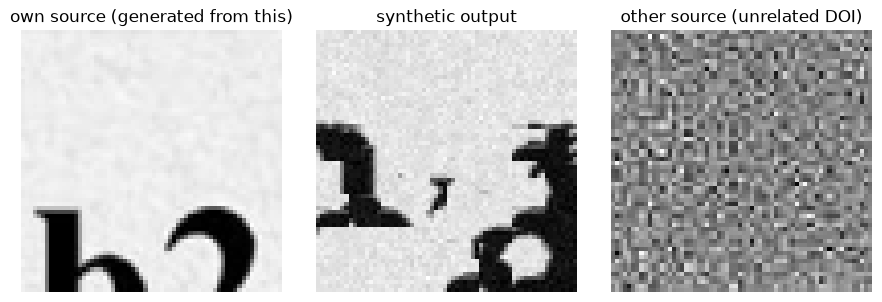

own source: 00655d9628, other source: 0144266d21


In [1]:
import sys, os
sys.path.append(os.path.join("..", "..", "src"))
import numpy as np
import matplotlib.pyplot as plt

from data.loader import DEV_SOURCE_IDS, load_generator_source, TEST_IDS
from data.pyramid import build_pyramid
from data.patches import extract_patches
from models.sampler import sample_coarse_to_fine
from evaluation.copying import cross_group_copying_report

OWN_SOURCE_ID = DEV_SOURCE_IDS[0]
OTHER_SOURCE_ID = DEV_SOURCE_IDS[1]

own_img, _ = load_generator_source(OWN_SOURCE_ID)
other_img, _ = load_generator_source(OTHER_SOURCE_ID)

CROP = 64
own_crop = own_img[:CROP, :CROP].astype(np.float64)
other_crop = other_img[:CROP, :CROP].astype(np.float64)

PATCH_SIZE, STRIDE, NUM_STEPS = 4, 4, 15  # Day 18's accepted fast default
pyramid = build_pyramid(own_crop, num_scales=4, scale_factor=0.5)
synthetic, _ = sample_coarse_to_fine(pyramid, PATCH_SIZE, STRIDE, NUM_STEPS, seed=0)

fig, axes = plt.subplots(1, 3, figsize=(9, 3))
for ax, title, im in zip(axes, ["own source (generated from this)", "synthetic output", "other source (unrelated DOI)"],
                          [own_crop, synthetic, other_crop]):
    ax.imshow(im, cmap="gray")
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.show()
print(f"own source: {OWN_SOURCE_ID}, other source: {OTHER_SOURCE_ID}")


## 2. Extract patches for the diagnostic

Same patch_size for all three patch sets, so hash/NCC comparisons are
apples-to-apples: the synthetic output's own patches, the real own-group
bank, and the real other-group bank.

In [2]:
DIAG_PATCH_SIZE = 8
synthetic_patches = extract_patches(synthetic, DIAG_PATCH_SIZE, DIAG_PATCH_SIZE).patches
own_group_patches = extract_patches(own_crop, DIAG_PATCH_SIZE, DIAG_PATCH_SIZE).patches
other_group_patches = extract_patches(other_crop, DIAG_PATCH_SIZE, DIAG_PATCH_SIZE).patches

print(f"synthetic patches: {len(synthetic_patches)}, own-group bank: {len(own_group_patches)}, "
      f"other-group bank: {len(other_group_patches)}")


synthetic patches: 64, own-group bank: 64, other-group bank: 64


## 3. Run the two-stage diagnostic, own-group vs other-group

Stage 1 (average-hash) finds candidates cheaply; stage 2 (normalized
cross-correlation) confirms only the real matches. `own_group_rate` is
expected to be non-trivial (the generator's denoiser is literally built
from these patches). `other_group_rate` should be near zero - any confirmed
match there is a genuine leak, not expected behavior.

In [3]:
report = cross_group_copying_report(synthetic_patches, own_group_patches, other_group_patches)

print(f"own-group copying rate:   {report['own_group_rate']:.1%}  "
      f"({len(report['own_confirmed'])} confirmed patch-level matches)")
print(f"other-group copying rate: {report['other_group_rate']:.1%}  "
      f"({len(report['other_confirmed'])} confirmed patch-level matches)")


own-group copying rate:   21.9%  (15 confirmed patch-level matches)
other-group copying rate: 0.0%  (0 confirmed patch-level matches)


## 4. Cross-group edge, extended: hidden test set

Per the spec, resemblance to the hidden TEST set is also a leak, reported
separately again. This is READ-ONLY evaluation: the TEST image below is
never fed to the generator, never used to build a patch bank, and never
used in any parameter/selection decision - `load_generator_source` would
refuse it for that (`guard.assert_lineage_is_test_safe`). We only load it
here, after generation is already complete, to check whether the finished
output happens to resemble it - the same kind of after-the-fact leak check
the copying diagnostic exists to do for any other group.

In [4]:
from PIL import Image
from data.loader import _EMPS_IMAGES_DIR

TEST_SOURCE_ID = sorted(TEST_IDS)[0]  # deterministic pick - set iteration order is NOT stable across process runs
test_path = os.path.join(_EMPS_IMAGES_DIR, TEST_SOURCE_ID + ".png")
test_img = np.array(Image.open(test_path).convert("L"))[:CROP, :CROP].astype(np.float64)
test_group_patches = extract_patches(test_img, DIAG_PATCH_SIZE, DIAG_PATCH_SIZE).patches

from evaluation.copying import copying_rate
test_rate, test_confirmed = copying_rate(synthetic_patches, test_group_patches)

print(f"hidden-test-set copying rate: {test_rate:.1%} ({len(test_confirmed)} confirmed patch-level matches)")
print(f"(source: {TEST_SOURCE_ID}, loaded read-only for this evaluation check only, never used in generation)")


hidden-test-set copying rate: 0.0% (0 confirmed patch-level matches)
(source: 0384c4e782, loaded read-only for this evaluation check only, never used in generation)


## Findings - own-group vs other-group vs hidden-test, reported separately

Never pooled, per the project's own rule - each number answers a different
question.

In [5]:
summary = {
    "own_group (expected)": report["own_group_rate"],
    "other_group (leak if >0)": report["other_group_rate"],
    "hidden_test (leak if >0)": test_rate,
}
for name, rate in summary.items():
    print(f"{name:26s}: {rate:.1%}")


own_group (expected)      : 21.9%
other_group (leak if >0)  : 0.0%
hidden_test (leak if >0)  : 0.0%


**Interpretation.** A non-zero own-group rate is not a defect - it is
the expected, designed behavior of a patch-based denoiser: the generator's
whole mechanism is a weighted recombination of the same image's own
patches, so some patches in the output will closely resemble patches in the
source they came from. What matters is the CONTRAST: other-group and
hidden-test rates should be at or near zero, since those images never
contributed anything to this generation run - any confirmed match there
would mean the diagnostic caught the generator reproducing content it was
never given, which is the actual leak this two-stage design exists to
catch.

**Caveat, stated per the spec:** this is a high-specificity gate, not a
high-sensitivity one. A zero rate here does not prove all semantic
similarity is absent - two unrelated EMPS images can share generic texture
statistics (fine SEM grain, common particle shapes) that this patch-level
hash+correlation check is not designed to flag as "copying". It answers
"is there a near-exact patch-level duplicate", not "is there any
resemblance at all".


## Layer 7, Day 20 status

- [x] Two-stage copying diagnostic (`src/evaluation/copying.py`) applied to
  a real generated image, not just synthetic self-test patches.
- [x] Cross-group edges reported separately: own-group, other-group
  (different EMPS DOI), and hidden-test-set - three numbers, never pooled.
- [x] High-specificity-not-sensitivity caveat stated explicitly, per spec.
- Carried forward: this used one source image, one seed, one patch size -
  a fuller Layer 7 pass (multiple sources/seeds) belongs with the
  downstream 3-arm experiment (Day 21-22), which needs the same copying
  guarantees against held-out groups anyway.
